In [1]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


La **classification** est un tâche de ML supervisé qui consiste à prédire une catégorie

**Types de classification**:
- **Binaire** : 2 classe (Survivant/décédé)
- **Multi-classe** : > 2 classes

**Algorithmes courants** :
- Régression logistique
- Arbres de décision
- Random Forest

## Analyse exploratoire

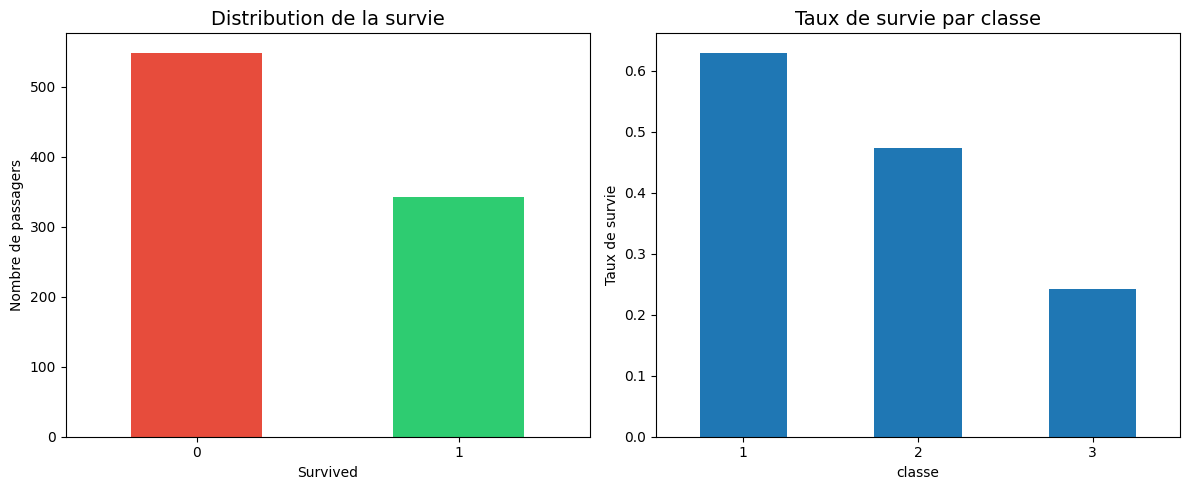

In [2]:
plt.figure(figsize=(12,5))

# Distribution global de la survie
plt.subplot(1, 2, 1)
titanic["survived"].value_counts().plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Distribution de la survie", fontsize=14)
plt.xlabel("Survived")
plt.ylabel("Nombre de passagers")
plt.xticks(rotation=0)

# Taux de survie par classe sociale
plt.subplot(1, 2, 2)
survival_class = titanic.groupby("pclass")["survived"].mean()
survival_class.plot(kind="bar")
plt.title("Taux de survie par classe", fontsize=14)
plt.xlabel("classe")
plt.ylabel("Taux de survie")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Gestion des valeurs manquantes

In [3]:
def analyse_missing_data(df):
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)

    missing_table = pd.DataFrame({
        "Colonnes": missing.index,
        "Valeurs manquantes": missing.values,
        "Pourcentage": missing_pct.values
    })

    missing_table = missing_table[missing_table["Valeurs manquantes"] > 0].sort_values("Pourcentage", ascending=False)

    return missing_table

missing_data = analyse_missing_data(titanic)
missing_data

,Colonnes,Valeurs manquantes,Pourcentage
11,deck,688,77.216611
3,age,177,19.865320
7,embarked,2,0.224467
12,embark_town,2,0.224467


## Prétraitement des données

In [4]:
features_to_keep = ["pclass", "sex", "age", "sibsp", "fare", "parch", "embarked"]
target = "survived"

X = titanic[features_to_keep].copy()
y = titanic[target].copy()

# Identification des types de colonnes
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.to_list()
categorical_features = X.select_dtypes(include=["object"]).columns.to_list()

print(f"Variables numériques : {numeric_features}")
print(f"Variables catégorielles : {categorical_features}")

Variables numériques : ['pclass', 'age', 'sibsp', 'fare', 'parch']
Variables catégorielles : ['sex', 'embarked']


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_3264\2447175797.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.to_list()


## Pipeline

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipeline pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # Remplace NaN par la médiane
    ("scaler", StandardScaler())
])

# Pipeline pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")), # remplace NaN par missing
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Appliquer les pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Séparation Train/Test

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% pour les tests, 80% pour l'entrainement
    random_state=42,
    stratify=y # Maintient les proportions de classes
)

print(f"Train : {y_train.mean():0.1%} de survivants")
print(f"Test : {y_test.mean():0.1%} de survivants")

Train : 38.3% de survivants
Test : 38.5% de survivants


## Régression logistique

Malgré son nom, la régression logistique est un aglorithme de classification

- Le seuil de décision (par défaut 0.5) : si P > 0.5 => classe 1, sinon classe 0

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

ml_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), # Transformation des données
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# Entrainement du modèle sur les données d'entrainement
ml_pipeline.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = ml_pipeline.predict(X_test)

print(y_pred)
print(y_test)

# Calcul du taux de bonnes prédictions
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:0.2%}")

[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0]
565    0
160    0
553    1
860    0
241    1
      ..
880    1
91     0
883    0
473    1
637    0
Name: survived, Length: 179, dtype: int64
Accuracy : 80.45%


## Sauvegarde du modèle

**joblib** permet de sauvegarder un modèle entraîné pour :
- Eviter de ré-entrainer le modèle à chaque utilisation
- Déployer en production
- Partager avec d'autres développeurs

Pipeline complète (preprocessing + modèle) est sauvegardé

In [8]:
import joblib

# Sauvegarde dans un fichier pkl
model_filename = "titanic_survival_model.pkl"
joblib.dump(ml_pipeline, model_filename)

['titanic_survival_model.pkl']

In [9]:
# Rechargement du modèle
loaded_model = joblib.load(model_filename)

new_passenger = pd.DataFrame({
    "pclass": [1],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [8],
    "embarked": ["S"]
})

prediction = loaded_model.predict(new_passenger)
proba = loaded_model.predict_proba(new_passenger)

print(f"Survie : {'OUI' if prediction[0] == 1 else 'NON'}")
print(f"proba survie : {proba[0][1]:.1%}")

Survie : OUI
proba survie : 50.4%


## Evaluation du modèle

-  **Précision** : parmi les prédictions positives, combien sont correctes ?
- **Recall** : parmi les vrais positifs, combien ont été détéctés ?
    - Important quand les faux négatifs sont couteux.
- **F1-score** : Moyenne entre précision et recall

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred, target_names=['Décédé', 'Vivant']))

              precision    recall  f1-score   support

      Décédé       0.81      0.89      0.85       110
      Vivant       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



- **TN (True negative)** : Correctement prédit comme négatif
- **TP (True Positive)** : Correctement prédit comme positif
- **FP (False Positive)** : Fausse alerte (prédit positif mais était négatif)
- **FN (False negative)** : Manqué (prédit comme négatif mais était positif)

[[98 12]
 [23 46]]


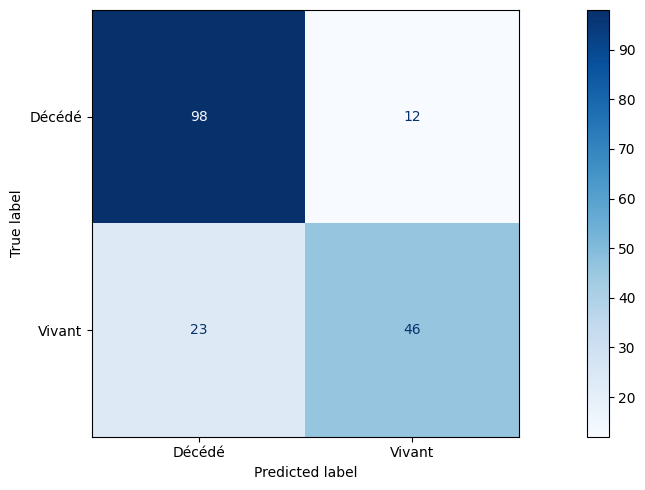

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

fig, axes = plt.subplots(1,1, figsize=(14,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Décédé', 'Vivant'])
disp.plot(ax=axes, cmap='Blues')
plt.tight_layout()
plt.show()


## Comparaison des modèles de classification

- **KNN** (K-Nearest Neighbors)
- **Decision tree** (Arbre de décision)
- **Random Forest** (Forêt aléatoire)
- **Ensemble learning** (Vote majoritaire)

## KNN

**KNN** est un algorithme simple basé sur la proximité
- Pour prédire la classe d'une nouvelle observation :
    - trouve les **K** voisin les plus proches
    - Regarde leurs classes
    - Prédit la classe majoritaire parmi ces K voisins

**Avantages**
- Très simple à comprendre
- Fonctionne bien avec peu de données

**Inconvénients**
- Très lent sur de gros datasets
- Très dépendant de la valeur K


In [12]:
from sklearn.neighbors import KNeighborsClassifier

kn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("classifier", KNeighborsClassifier()) # k = 5 par défaut
])

kn_pipeline.fit(X_train, y_train)

y_pred_kn = kn_pipeline.predict(X_test)

print(accuracy_score(y_test, y_pred_kn))
print(classification_report(y_test, y_pred_kn))

0.8156424581005587
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



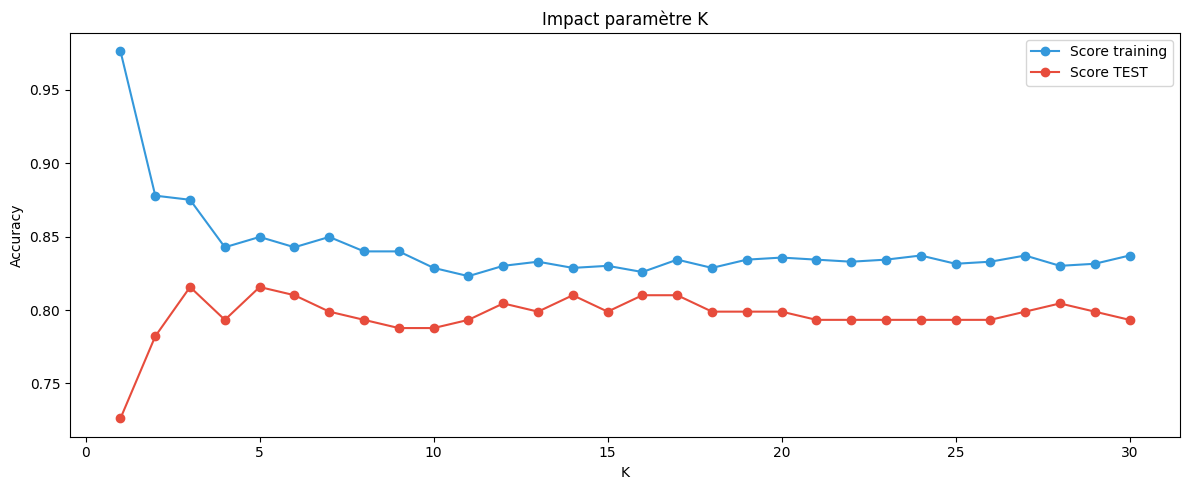

3


In [13]:
k_values = range(1, 31)
train_score = []
test_score = []

for k in k_values:
    knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)
    train_score.append(knn.score(X_train, y_train))
    test_score.append(knn.score(X_test, y_test))

plt.figure(figsize=(12,5))
plt.plot(k_values, train_score, label="Score training", marker='o', color="#3498db")
plt.plot(k_values, test_score, label="Score TEST", marker='o', color="#e74c3c")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Impact paramètre K")
plt.legend()
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(test_score)]
print(best_k)

## Decision tree

Un arbre de décision prend des décisions séquentielles :

1. à chaque noeud, l'arbre trouve la meilleure question
2. La meilleure question = celle qui sépare le mieux les classes

**Avantages**:
- Très interpretable (on peut visualiser l'arbre)
- Gère automatiquement les features catégorielles et numérique
- Pas besoin de normalisation
- Capture les relations non-linéaires

**inconvénients** :
- Tendance à l'**overfitting** (mémorise le training)


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt_test = dt_pipeline.predict(X_test)
y_pred_dt_train = dt_pipeline.predict(X_train)

print(f"Train : {accuracy_score(y_train, y_pred_dt_train)}")
print(f"Test : {accuracy_score(y_test, y_pred_dt_test)}")


Train : 0.9831460674157303
Test : 0.8268156424581006


## Random Forest

Random forest est un ensemble d'arbres de décision

1. Crée plusieurs arbres de décision (100 par défaut)
2. Chaque arbre est entrainé sur un échantillon aléatoire des données
3. Pour prédire : chaque arbre vote, la classe majoritaire l'emporte

**Avantages** :
- Excellentes performances
- Robuste à l'overfitting
- Fournit l'importance des features

**Inconvénients**:
- Moins interprétable qu'un seul arbre
- Plus lent à entraîner et prédire
- Consomme plus de mémoire 

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print(accuracy_score(y_test, y_pred_rf))

0.8212290502793296


## Ensemble learning

L'idée est de combiner plusieurs modèles différents pour améliorer les performances

**Principe du Voting classifier**:
1. Entraîne plusieurs modèles différents
2. chaque modèle donne son avis
3. La prédiction finale est déterminée par vote

**types de vote**:
- **Hard voting**: Vote majoritaire simple (chaque modèle vote pour une classe)
- **Soft voting**: Vote pondéré par les probabilités

**Avantages**:
- Souvent meilleures performances qu'un modèle seul
- Plus robuste

**Inconvénients**:
- Plus lent
- Plus complexe à maintenir 

In [16]:
from sklearn.ensemble import VotingClassifier

estimators = [
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('lr', LogisticRegression(random_state=42)),
]

voting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', VotingClassifier(
        estimators=estimators,
        voting='soft'
    ))
])

voting_pipeline.fit(X_train, y_train)

y_pred_voting = voting_pipeline.predict(X_test)

print(accuracy_score(y_test, y_pred_voting))

0.8212290502793296


## Feature importance

Le **feature importance** mesure la contribution de chaque variable à la qualité des prédictions du modèle.

utilité:
- comprendre quelles variables expliquent la survie
- Détecter les variables inutiles

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_3264\3584510232.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


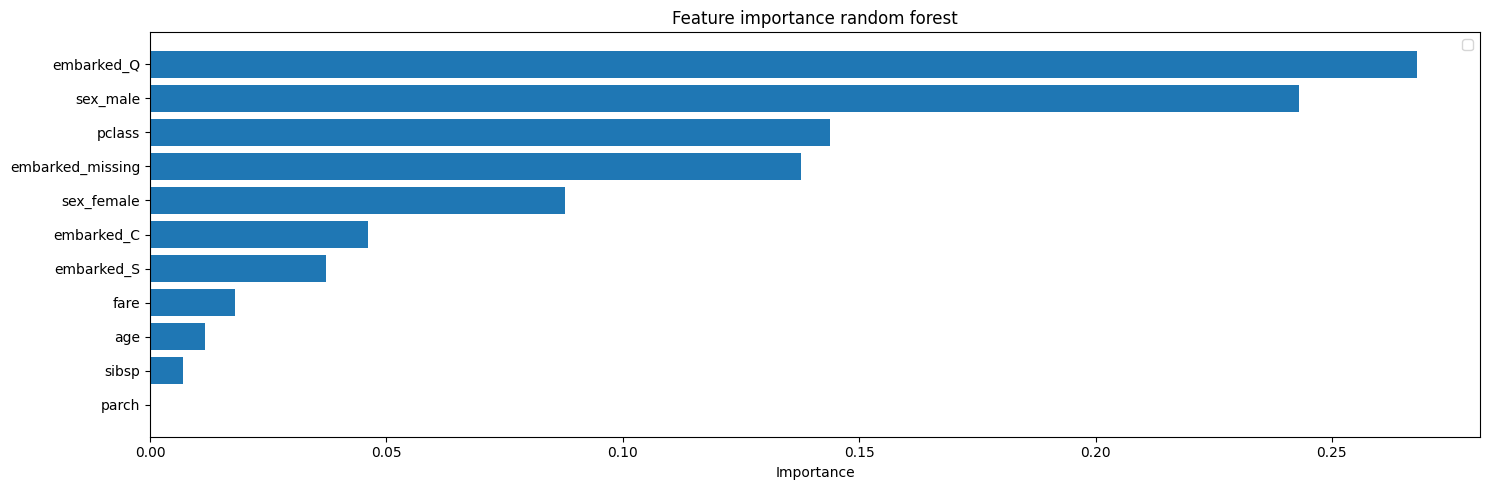

In [17]:
# Noms des features apres onehot
rf_clf = rf_pipeline.named_steps["classifier"]
preprocessor_fit = rf_pipeline.named_steps["preprocessor"]

ohe = preprocessor_fit.named_transformers_['cat'].named_steps['onehot']
cat_features = ohe.get_feature_names_out(categorical_features).tolist()
all_features = cat_features + numeric_features

# importances
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

sorted_names = [all_features[i] for i in indices]
sorted_imp = importances[indices]

# Visualisation
fig, axes = plt.subplots(1, 1, figsize=(15,5))

axes.barh(range(len(sorted_imp)), sorted_imp[::-1])
axes.set_yticks(range(len(sorted_imp)))
axes.set_yticklabels(sorted_names[::-1], fontsize=10)
axes.set_xlabel("Importance", fontsize=10)
axes.set_title("Feature importance random forest")
axes.legend()
plt.tight_layout()
plt.show()



C:\Users\Administrateur\AppData\Local\Temp\ipykernel_3264\477734964.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_3264\477734964.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


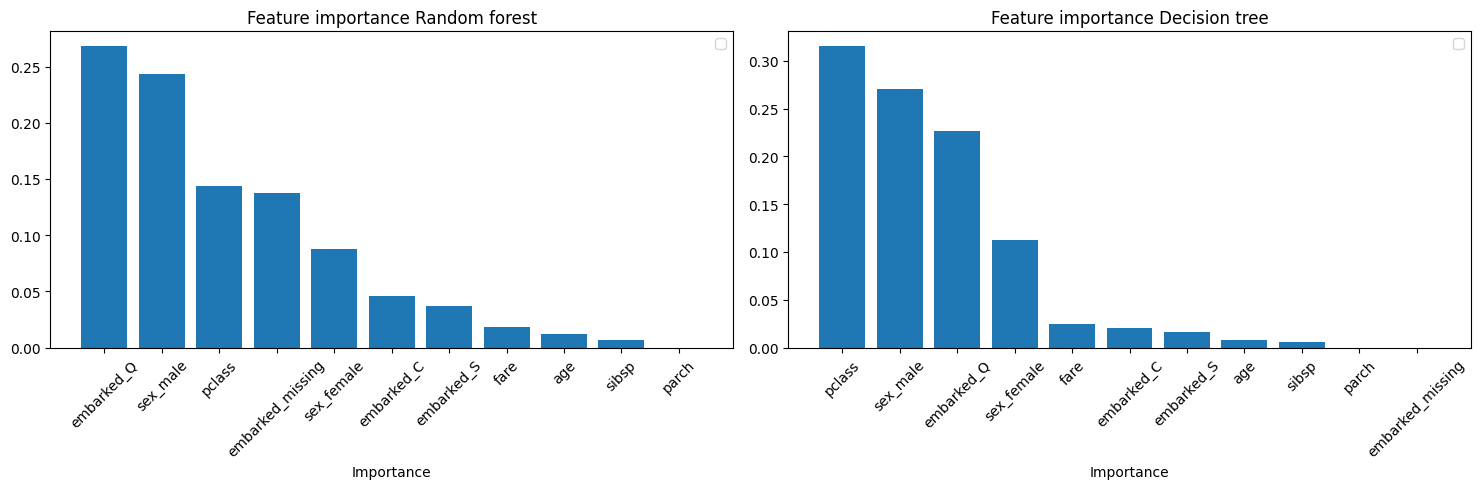

In [18]:
dt_clf = dt_pipeline.named_steps["classifier"]
dt_importances = dt_clf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(15,5))

for ax, (imp, title) in zip(axes, [
    (importances, "Random forest"),
    (dt_importances, "Decision tree")
]):
    idx = np.argsort(imp)[::-1]
    ax.bar(range(len(imp)), imp[idx])
    ax.set_xticks(range(len(imp)))
    ax.set_xticklabels([all_features[i] for i in idx], fontsize=10, rotation=45)
    ax.set_xlabel("Importance", fontsize=10)
    ax.set_title(f"Feature importance {title}")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# pip install shap
import shap

# Préparer les données => Shap ne peut pas travailler directement avec une pipeline Sklearn
X_train_prep = rf_pipeline.named_steps["preprocessor"].transform(X_train)
X_test_prep = rf_pipeline.named_steps["preprocessor"].transform(X_test)

rf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shap.fit(X_train_prep, y_train)

# TreeExplainer est optimisé pour les modèles d'arbres
explainer = shap.TreeExplainer(rf_shap)

# Shap retourne maintenant un tableau 3D : (n_observation, n_features, n_class)
# On doit découper pour avoir un tableau par classe
# shap_values[0] => pour la classe 1 (decede)
# shap_values[1] => pour la classe 0 (survivant)
shap_values_raw = explainer.shap_values(X_test_prep)

shap_values = [shap_values_raw[:,:, i] for i in range(shap_values_raw.shape[2])]

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Summary plot (Vue global)

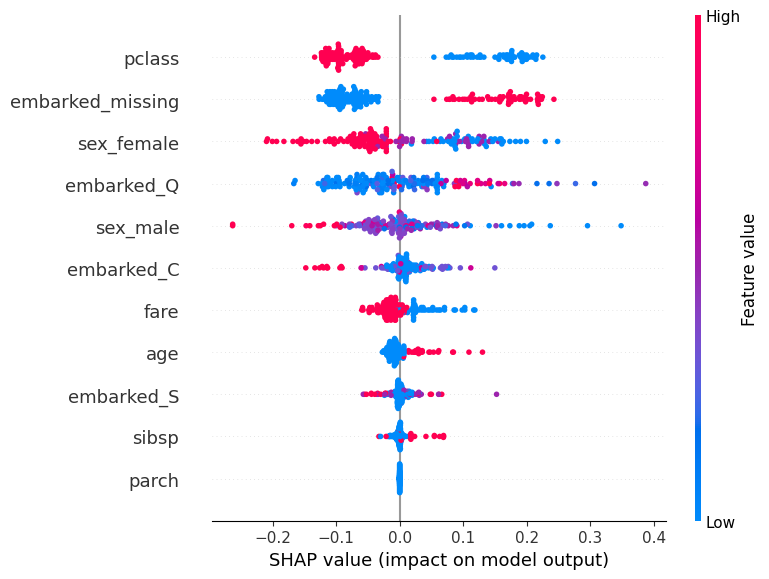

In [21]:
shap.summary_plot(
    shap_values[1],
    X_test_prep,
    feature_names=all_features,
    plot_type="dot"
)

## Shap local (waterfall plot) : explication d'une prédiction individuelle 

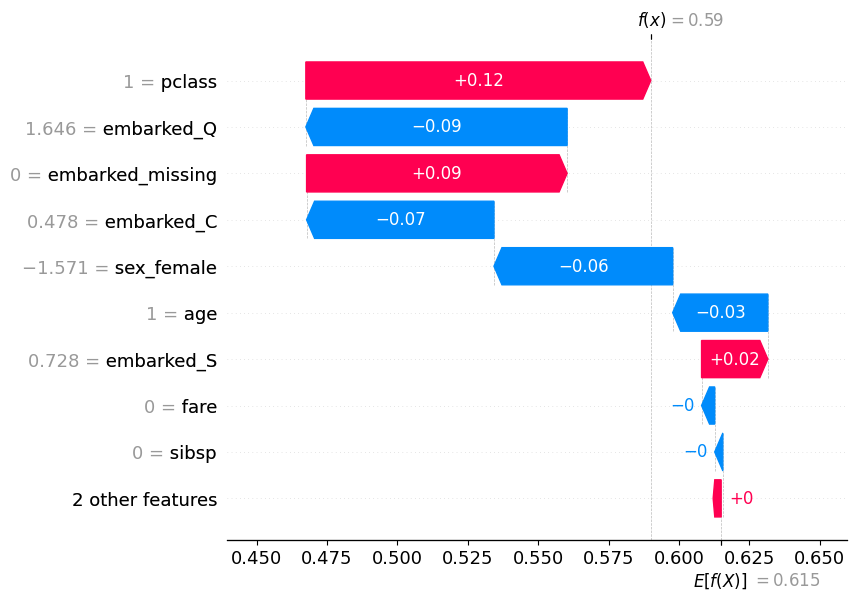

In [25]:
idx = 8
instance = X_test_prep[idx]
true_label = y_test.iloc[idx]
pred_proba = rf_shap.predict_proba([instance])[0][1]
pred_label = rf_shap.predict([instance])[0]

expected_val = explainer.expected_value

shap_exp = shap.Explanation(
    values=shap_values[0][idx],
    base_values=expected_val[0],
    data=instance,
    feature_names=all_features
)

shap.waterfall_plot(shap_exp)